# 🌳 Decision Trees — Hands-On Workshop Notebook

**Domain:** Medical Diagnosis  
**Dataset:** Heart Disease Prediction (Medical) 

**Tools:** `scikit-learn`, `pandas`, `matplotlib`, `seaborn`

---

## 🗺️ Notebook Roadmap

| # | Section | Key Concepts |
|---|---------|--------------|
| 1 | Setup & Data Exploration | EDA, class balance, feature types |
| 2 | Entropy & Gini — Manual Calculation | Information theory intuition |
| 3 | Building Your First Decision Tree | Classifier, fit, predict |
| 4 | Visualising the Tree | plot_tree, export_text |
| 5 | Evaluating the Model | Accuracy, Precision, Recall, F1, ROC-AUC |
| 6 | Hyperparameter Tuning with GridSearchCV | max_depth, min_samples, criterion |
| 7 | Feature Importance | NIG, business insights |


> **Tip:** Run each cell in order. Each section builds on the previous one.

---

## Section 1 — Setup & Data Exploration

We use the **Heart Disease dataset** (UCI / Kaggle) — a medical classification problem.

> **Clinical Goal:** Predict whether a patient has heart disease (1) or not (0)  
> based on 13 clinical features like age, cholesterol, chest pain type, etc.

This is an ideal dataset for Decision Trees because:
- Features are a mix of numerical and categorical
- The logic maps to real medical triage decisions
- Interpretability is critical in healthcare

In [15]:
# ── Install (run once if needed) ──────────────────────────────────────────────
# !pip install scikit-learn pandas matplotlib seaborn numpy --quiet

In [16]:
# ── Core imports ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

# ── Plotting style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
TEAL = '#028090'
CORAL = '#E05C4B'
GOLD  = '#E8A838'
print("All libraries imported successfully!")

All libraries imported successfully!


In [17]:
# Reading the dataset and basic EDA

df = pd.read_csv('heart_disease_data.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nTarget Distribution:")
print(df['HeartDisease'].value_counts().rename({0: 'No Disease', 1: 'Heart Disease'}))
print(f"\n   Class balance: {df['HeartDisease'].mean()*100:.1f}% positive")
df.head()

Dataset shape: (918, 12)

Target Distribution:
HeartDisease
Heart Disease    723
No Disease       195
Name: count, dtype: int64

   Class balance: 78.8% positive


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,57,0,0,122,106,0,2,65,1,0.0,1,1
1,51,1,2,101,290,0,2,169,0,1.1,1,1
2,58,1,3,111,180,0,2,155,1,0.3,1,1
3,66,0,1,154,187,1,0,92,0,0.4,0,1
4,50,0,3,129,162,0,0,120,1,1.6,1,1


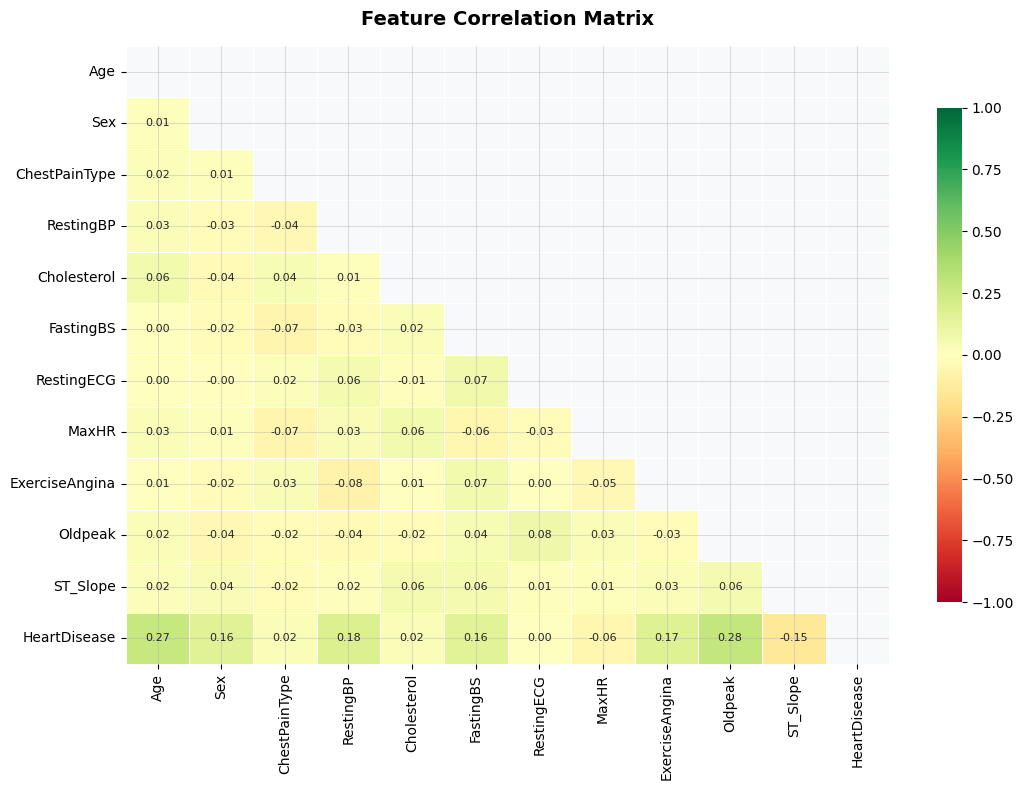

In [18]:
# ── Exploratory Data Analysis ─────────────────────────────────────────────────
# ── Correlation Heatmap ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=ax, cbar_kws={'shrink': 0.8},
            linewidths=0.5, annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

📌 Observation: 

OldPeak, Age, RestingBP, ExerciseAngina, SexRestingBS are positively correlated with HeartDisease,

while ST_Slope, MaxHR are negatively correlated — indicating that up-slope patterns are protective.

---

## Section 2 — Entropy & Gini: Manual Calculation

Before we let sklearn do the heavy lifting, we build the math from scratch.

> **Why this matters:** Understanding entropy intuitively helps you diagnose tree behaviour,  
> debug unexpected splits, and explain your model to stakeholders.

### Key Formulas
$$H(Y) = -\sum_{i} P(y_i) \cdot \log_2 P(y_i)$$
$$G(Y) = 1 - \sum_{i} P(y_i)^2$$
$$\text{IG} = H_{\text{parent}} - \frac{n_L}{n} H_L - \frac{n_R}{n} H_R$$

In [19]:
# ── Entropy & Gini from scratch ───────────────────────────────────────────────
def entropy(y):
    # Shannon entropy of a label array
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    # Avoid log(0) — convention: 0 * log(0) = 0
    return -np.sum([p * np.log2(p) for p in probs if p > 0])

def gini(y):
    # Gini impurity of a label array
    classes, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return 1 - np.sum(probs ** 2)

def information_gain(y_parent, y_left, y_right):
    # Information Gain of a split
    n  = len(y_parent)
    nL = len(y_left)
    nR = len(y_right)
    ig = entropy(y_parent) - (nL/n * entropy(y_left)) - (nR/n * entropy(y_right))
    return ig

# ── Worked example on our dataset ─────────────────────────────────────────────
y = df['HeartDisease'].values
print(f"Parent node n = {len(y)}")
print(f"   Entropy  H = {entropy(y):.4f}")
print(f"   Gini     G = {gini(y):.4f}")
print()

# Split on ExerciseAngina (binary feature)
y_ang_yes = df[df['ExerciseAngina'] == 1]['HeartDisease'].values
y_ang_no  = df[df['ExerciseAngina'] == 0]['HeartDisease'].values

print(f"Split on ExerciseAngina:")
print(f"   Angina=Yes  → n={len(y_ang_yes)}, H={entropy(y_ang_yes):.4f}, G={gini(y_ang_yes):.4f}, "
      f"disease_rate={y_ang_yes.mean()*100:.1f}%")
print(f"   Angina=No   → n={len(y_ang_no)}, H={entropy(y_ang_no):.4f}, G={gini(y_ang_no):.4f}, "
      f"disease_rate={y_ang_no.mean()*100:.1f}%")
print(f"   Information Gain = {information_gain(y, y_ang_yes, y_ang_no):.4f}")
print()

# Compare with Cholesterol split at median
median_chol = df['Cholesterol'].median()
y_high_chol = df[df['Cholesterol'] > median_chol]['HeartDisease'].values
y_low_chol  = df[df['Cholesterol'] <= median_chol]['HeartDisease'].values

print(f"Split on Cholesterol > {median_chol:.0f} (median):")
print(f"   High Chol → n={len(y_high_chol)}, H={entropy(y_high_chol):.4f}, "
      f"disease_rate={y_high_chol.mean()*100:.1f}%")
print(f"   Low  Chol → n={len(y_low_chol)}, H={entropy(y_low_chol):.4f}, "
      f"disease_rate={y_low_chol.mean()*100:.1f}%")
print(f"   Information Gain = {information_gain(y, y_high_chol, y_low_chol):.4f}")

Parent node n = 918
   Entropy  H = 0.7461
   Gini     G = 0.3346

Split on ExerciseAngina:
   Angina=Yes  → n=348, H=0.5395, G=0.2166, disease_rate=87.6%
   Angina=No   → n=570, H=0.8366, G=0.3911, disease_rate=73.3%
   Information Gain = 0.0221

Split on Cholesterol > 197 (median):
   High Chol → n=458, H=0.7365, disease_rate=79.3%
   Low  Chol → n=460, H=0.7554, disease_rate=78.3%
   Information Gain = 0.0001


📌 Analysis: 

ExerciseAngina gives higher IG than the median Cholesterol split

This aligns with clinical intuition — exercise-induced angina is a strong predictor.

---

## Section 3 — Building Your First Decision Tree

We now let sklearn find the best splits automatically using the math from Section 2.

In [20]:
# ── Prepare features ──────────────────────────────────────────────────────────
FEATURES = ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol',
            'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']
TARGET = 'HeartDisease'

X = df[FEATURES]
y = df[TARGET]

# ── Train / Test split (stratified to preserve class balance) ─────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Test set     : {X_test.shape[0]} samples")
print(f"Train positives: {y_train.mean()*100:.1f}%  |  Test positives: {y_test.mean()*100:.1f}%")
print("\nStratified split ensures class balance is preserved in both splits.")

Training set : 734 samples
Test set     : 184 samples
Train positives: 78.7%  |  Test positives: 78.8%

Stratified split ensures class balance is preserved in both splits.


In [21]:
# ── Train a Decision Tree Classifier ──────────────────────────────────────────
clf = DecisionTreeClassifier(
    criterion='gini',        # split quality measure
    max_depth=4,             # limit depth to avoid overfitting
    min_samples_leaf=15,     # each leaf needs at least 15 patients
    random_state=42
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print("Model trained!\n")
print(f"   Tree depth   : {clf.get_depth()}")
print(f"   Leaf nodes   : {clf.get_n_leaves()}")
print(f"   Train Acc    : {clf.score(X_train, y_train)*100:.2f}%")
print(f"   Test  Acc    : {clf.score(X_test,  y_test)*100:.2f}%")
print(f"   ROC-AUC      : {roc_auc_score(y_test, y_prob):.4f}")

Model trained!

   Tree depth   : 4
   Leaf nodes   : 15
   Train Acc    : 83.24%
   Test  Acc    : 84.24%
   ROC-AUC      : 0.7845


---

## Section 4 — Visualising the Decision Tree

Decision Trees are uniquely interpretable — you can read the exact rules the model learned!

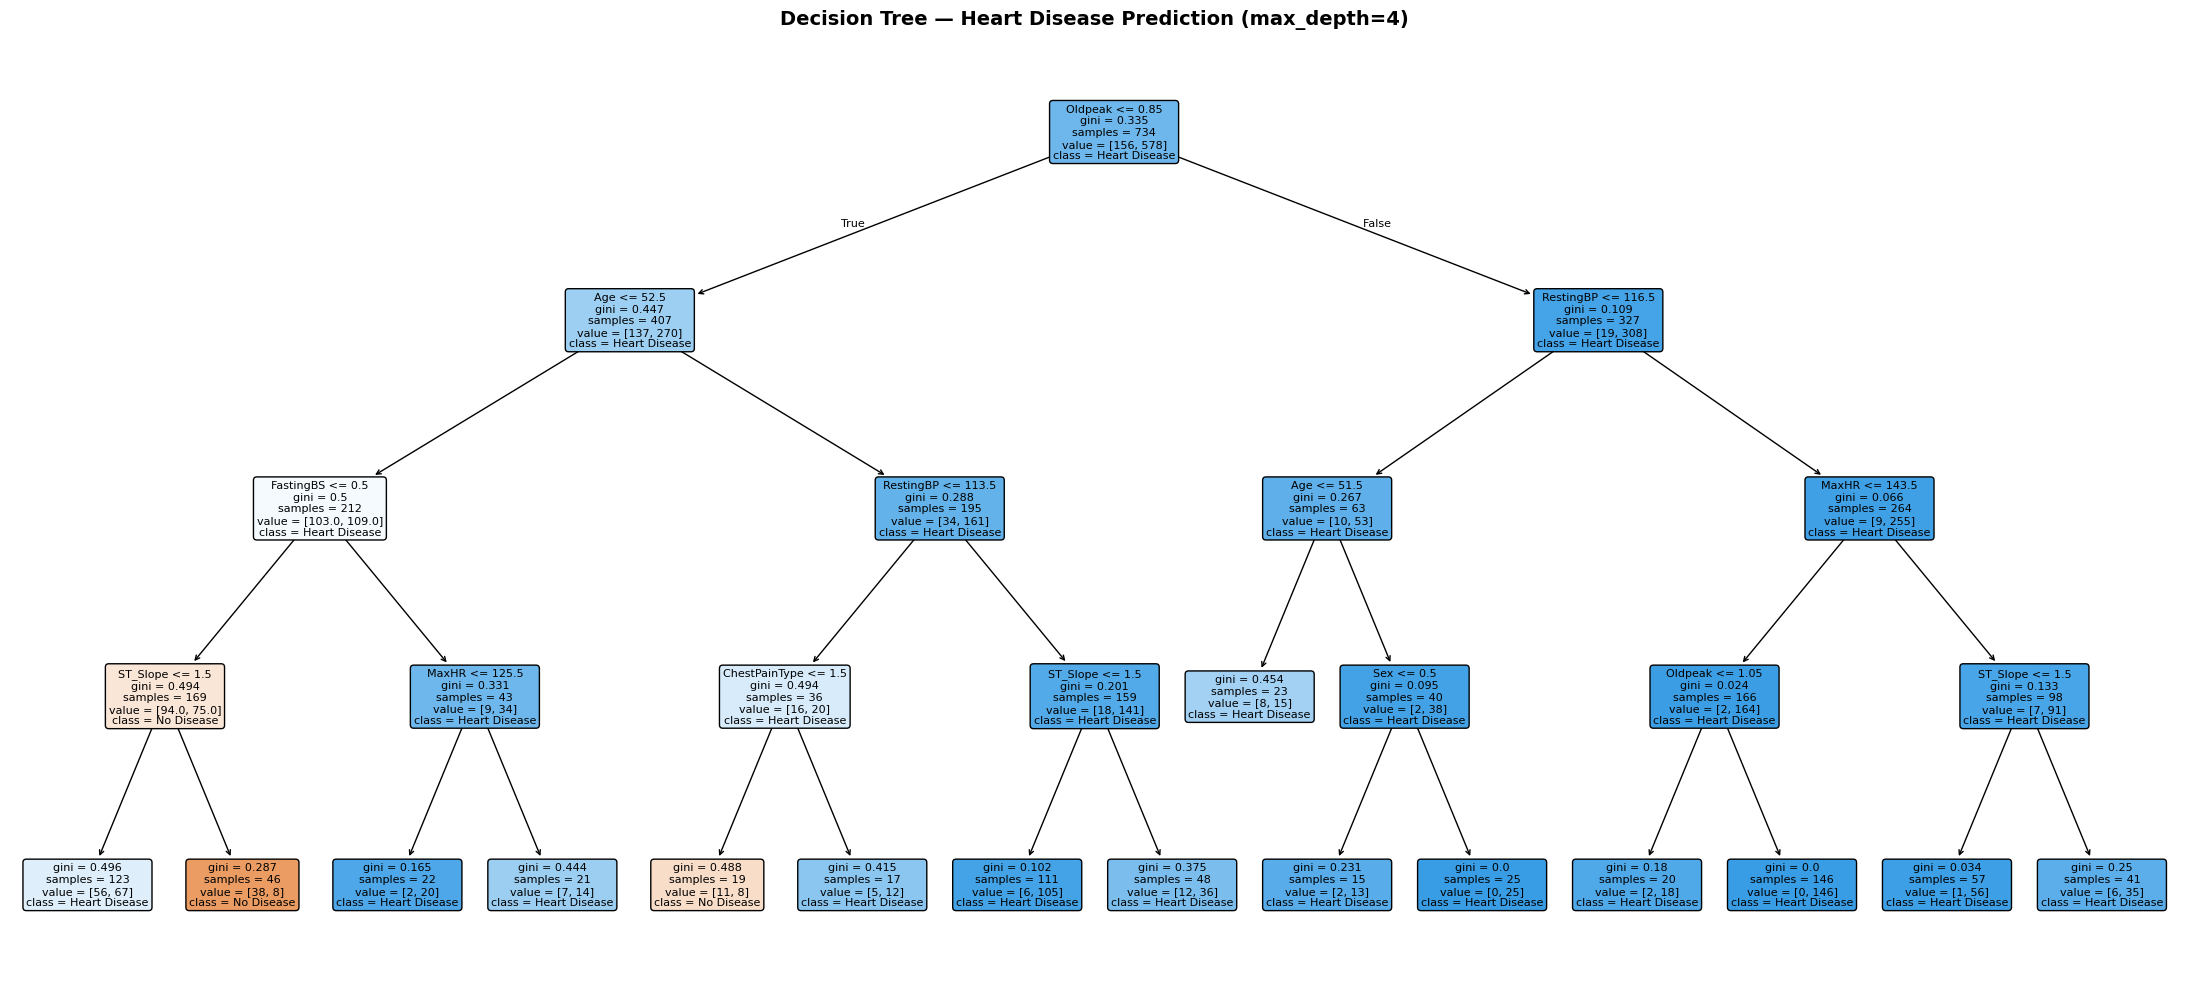

In [22]:
# ── Plot the tree ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    clf,
    feature_names=FEATURES,
    class_names=['No Disease', 'Heart Disease'],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    fontsize=8,
    ax=ax
)
ax.set_title('Decision Tree — Heart Disease Prediction (max_depth=4)',
             fontsize=14, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('decision_tree_visual.png', dpi=130, bbox_inches='tight')
plt.show()

📌 Reading the tree:

• Blue nodes  → majority class = Heart Disease

• Orange nodes → majority class = No Disease

• Darker shade = purer node (lower gini)

• Root split → the single most powerful clinical feature

In [23]:
# ── Text representation of first 3 levels ────────────────────────────────────
rules = export_text(clf, feature_names=FEATURES, max_depth=3, show_weights=True)
print("Decision Rules (top 3 levels):\n")
print(rules[:2500])

Decision Rules (top 3 levels):

|--- Oldpeak <= 0.85
|   |--- Age <= 52.50
|   |   |--- FastingBS <= 0.50
|   |   |   |--- ST_Slope <= 1.50
|   |   |   |   |--- weights: [56.00, 67.00] class: 1
|   |   |   |--- ST_Slope >  1.50
|   |   |   |   |--- weights: [38.00, 8.00] class: 0
|   |   |--- FastingBS >  0.50
|   |   |   |--- MaxHR <= 125.50
|   |   |   |   |--- weights: [2.00, 20.00] class: 1
|   |   |   |--- MaxHR >  125.50
|   |   |   |   |--- weights: [7.00, 14.00] class: 1
|   |--- Age >  52.50
|   |   |--- RestingBP <= 113.50
|   |   |   |--- ChestPainType <= 1.50
|   |   |   |   |--- weights: [11.00, 8.00] class: 0
|   |   |   |--- ChestPainType >  1.50
|   |   |   |   |--- weights: [5.00, 12.00] class: 1
|   |   |--- RestingBP >  113.50
|   |   |   |--- ST_Slope <= 1.50
|   |   |   |   |--- weights: [6.00, 105.00] class: 1
|   |   |   |--- ST_Slope >  1.50
|   |   |   |   |--- weights: [12.00, 36.00] class: 1
|--- Oldpeak >  0.85
|   |--- RestingBP <= 116.50
|   |   |--- Age <

📌 Interpretation: 

Follow any path from root to leaf to understand why the model classifies a particular patient as high-risk.

---

## Section 5 — Evaluating the Model

Accuracy alone is insufficient for medical classification.  
A model that predicts "no disease" for everyone gets ~55% accuracy but misses all patients!

> **In clinical settings:** False Negatives (missing sick patients) are far more costly  
> than False Positives (unnecessarily worrying a healthy person).  
> → Prioritise **Recall** for the positive class.

In [24]:
# ── Full Classification Report ────────────────────────────────────────────────
print("=" * 60)
print("CLASSIFICATION REPORT — Heart Disease Prediction")
print("=" * 60)
print(classification_report(y_test, y_pred,
      target_names=['No Disease', 'Heart Disease']))
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_prob):.4f}")

CLASSIFICATION REPORT — Heart Disease Prediction
               precision    recall  f1-score   support

   No Disease       0.86      0.31      0.45        39
Heart Disease       0.84      0.99      0.91       145

     accuracy                           0.84       184
    macro avg       0.85      0.65      0.68       184
 weighted avg       0.84      0.84      0.81       184

ROC-AUC Score : 0.7845


📌 Metric Interpretation:

• Precision = Of all patients predicted as “Heart Disease”, how many actually have the disease?

• Recall    = Of all truly sick patients, how many did we catch?

• F1-Score  = Harmonic mean of precision & recall

• ROC-AUC   = Model's ability to discriminate between classes (0.5=random, 1.0=perfect) OR (Probability that the model ranks a randomly chosen sick patient higher than a healthy one.)

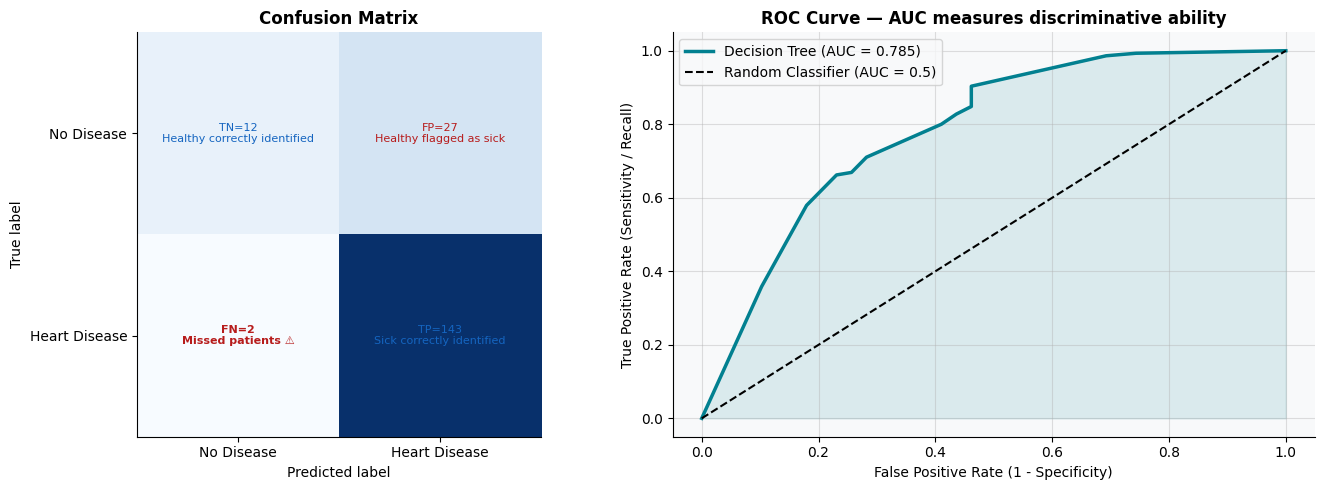

In [25]:
# ── Confusion Matrix + ROC Curve (side by side) ───────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Heart Disease'])
disp.plot(ax=ax1, cmap='Blues', colorbar=False)
for text in ax1.texts:
    text.set_visible(False)
ax1.set_title('Confusion Matrix', fontweight='bold', fontsize=12)
ax1.grid(False)

# Annotate with clinical meaning
tn, fp, fn, tp = cm.ravel()
ax1.text(0, 0, f'TN={tn}\nHealthy correctly identified',
         ha='center', va='center', fontsize=8, color='#1565C0')

ax1.text(1, 0, f'FP={fp}\nHealthy flagged as sick',
         ha='center', va='center', fontsize=8, color='#B71C1C')

ax1.text(0, 1, f'FN={fn}\nMissed patients ⚠️',
         ha='center', va='center', fontsize=8, color='#B71C1C', fontweight='bold')

ax1.text(1, 1, f'TP={tp}\nSick correctly identified',
         ha='center', va='center', fontsize=8, color='#1565C0')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
ax2.plot(fpr, tpr, color=TEAL, lw=2.5, label=f'Decision Tree (AUC = {auc:.3f})')
ax2.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier (AUC = 0.5)')
ax2.fill_between(fpr, tpr, alpha=0.12, color=TEAL)
ax2.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=10)
ax2.set_ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=10)
ax2.set_title('ROC Curve — AUC measures discriminative ability', fontweight='bold', fontsize=12)
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig('evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

Sensitivity = Recall = TPR = TP / (FN + TP)​ => Out of all actually sick patients, how many did we correctly detect?

Specificity = TN / (FP + TN) => Out of all healthy patients, how many did we correctly identify?​

📌 Observation: 

Our model substantially outperforms the random baseline.

An AUC of 0.785 means that, given a randomly selected pair of one sick and one healthy patient, the model correctly assigns a higher risk score to the sick patient about 78.5% of the time.

---

## Section 7 — Hyperparameter Tuning with GridSearchCV

Instead of manually sweeping one parameter, GridSearchCV exhaustively tests all combinations.  
It uses **k-fold cross-validation** to get a robust estimate for each configuration.

In [27]:
# ── Grid Search ───────────────────────────────────────────────────────────────
param_grid = {
    'criterion':        ['gini', 'entropy'],
    'max_depth':        [3, 4, 5, 6, 7],
    'min_samples_leaf': [5, 10, 15, 20],
    'min_samples_split': [10, 20, 30],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
    return_train_score=True,
)

print("Running GridSearchCV (5-fold CV × 120 combinations)...")
grid_search.fit(X_train, y_train)

best = grid_search.best_estimator_
print(f"\nBest Parameters:")
for k, v in grid_search.best_params_.items():
    print(f"   {k:25s} = {v}")

print(f"\n   CV ROC-AUC  : {grid_search.best_score_:.4f}")
print(f"   Test ROC-AUC: {roc_auc_score(y_test, best.predict_proba(X_test)[:,1]):.4f}")
print(f"   Test Accuracy: {best.score(X_test, y_test)*100:.2f}%")

Running GridSearchCV (5-fold CV × 120 combinations)...

Best Parameters:
   criterion                 = gini
   max_depth                 = 4
   min_samples_leaf          = 15
   min_samples_split         = 10

   CV ROC-AUC  : 0.8039
   Test ROC-AUC: 0.7845
   Test Accuracy: 84.24%


---

## Section 8 — Feature Importance

Feature importance in Decision Trees = **Normalised Information Gain** —  
how much impurity reduction each feature contributed, weighted by the fraction of samples it saw.

> **Clinical insight:** This tells doctors which measurements are most predictive of heart disease.

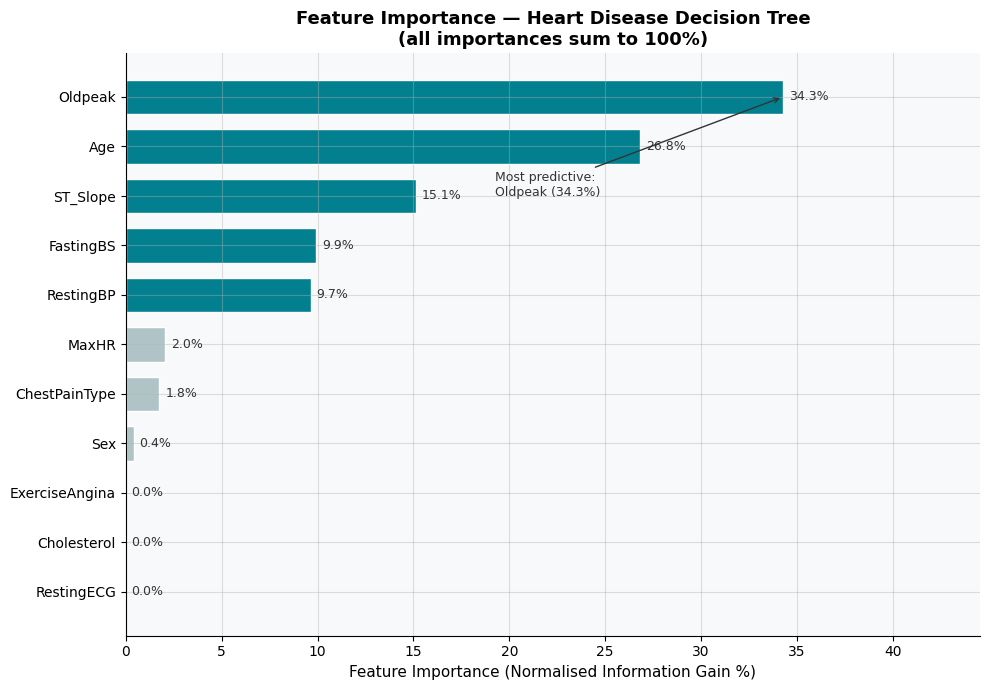


📌 Clinical Analysis:
   1. Oldpeak              — 34.3% : Strongest predictor
   2. Age                  — 26.8% : Second most important
   3. ST_Slope             — 15.1% : Third most important

   Features with near-zero importance: ['RestingECG', 'Cholesterol', 'ExerciseAngina', 'Sex']
   → These could be dropped for a leaner model without sacrificing performance.

⚠️  If any ONE feature dominates at >90%, suspect data leakage!


In [28]:
# ── Feature Importance from best model ────────────────────────────────────────
importances = pd.Series(best.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [TEAL if v > 0.08 else '#B0C4C8' for v in importances.values]
bars = ax.barh(importances.index, importances.values * 100, color=colors, edgecolor='white', height=0.7)

# Value labels
for bar, val in zip(bars, importances.values * 100):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9, color='#333')

ax.set_xlabel('Feature Importance (Normalised Information Gain %)', fontsize=11)
ax.set_title('Feature Importance — Heart Disease Decision Tree\n(all importances sum to 100%)',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, importances.values.max() * 130)

# Add clinical annotation for top feature
top_feat = importances.index[-1]
top_val  = importances.values[-1] * 100
ax.annotate(f'Most predictive:\n{top_feat} ({top_val:.1f}%)',
            xy=(top_val, len(importances)-1),
            xytext=(top_val - 15, len(importances)-3),
            arrowprops=dict(arrowstyle='->', color='#333'),
            fontsize=9, color='#333')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

print("\n📌 Clinical Analysis:")
print(f"   1. {importances.index[-1]:20s} — {importances.values[-1]*100:.1f}% : Strongest predictor")
print(f"   2. {importances.index[-2]:20s} — {importances.values[-2]*100:.1f}% : Second most important")
print(f"   3. {importances.index[-3]:20s} — {importances.values[-3]*100:.1f}% : Third most important")
near_zero = [f for f, v in zip(importances.index, importances.values) if v < 0.01]
if near_zero:
    print(f"\n   Features with near-zero importance: {near_zero}")
    print(f"   → These could be dropped for a leaner model without sacrificing performance.")
print("\n⚠️  If any ONE feature dominates at >90%, suspect data leakage!")